# Lung manuscript figures

This notebook is **visualization only**. It consumes the frozen lung `.h5ad`, benchmark tables/predictions, and GLMM outputs. It does **not** rerun preprocessing, classifiers, donor CV, donor ablation, or mixed models. UMAP coordinates are the only derived figure artifact and are cached separately.

In [1]:
from pathlib import Path
import sys

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src" / "scrna_benchmark").is_dir():
            return p
    raise RuntimeError("Run this notebook from inside the repository.")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

from scrna_benchmark.plotting import (
    DEFAULT_REP_LABELS,
    DEFAULT_REP_ORDER,
    load_per_class_f1_matrix,
    plot_batch_covariate_by_scheme,
    plot_confusion_matrix_from_predictions,
    plot_donor_ablation,
    plot_glmm_scheme_comparison,
    plot_per_class_f1_heatmap,
    plot_random_vs_donor_cv,
)

ADATA_PATH = REPO_ROOT / "data/lung/lung_benchmark_ready.h5ad"
PRIMARY_DIR = REPO_ROOT / "results/lung_no_batch_L4"
BATCH_DIR = REPO_ROOT / "results/lung_with_batch_L4"
QC_DIR = REPO_ROOT / "results/preprocessing/lung"
FIG_DIR = REPO_ROOT / "figures/lung"
CACHE_DIR = REPO_ROOT / "results/figure_data"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
print(REPO_ROOT)

/users/xchen5/scRNA-cross-donor-generalization


## 1. Required result availability

In [2]:
required = [
    ADATA_PATH,
    PRIMARY_DIR / "random_split/random_split_repeated_metrics.csv",
    PRIMARY_DIR / "donor_cv/metrics.csv",
    PRIMARY_DIR / "donor_ablation/donor_ablation_summary.csv",
    BATCH_DIR / "random_split/random_split_repeated_metrics.csv",
    BATCH_DIR / "donor_cv/metrics.csv",
    PRIMARY_DIR / "mixed_models/correctness_glmm_predicted_probabilities.csv",
]
missing = [p for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(f"Missing required result files: {missing}")
print("All required numerical outputs are available.")

All required numerical outputs are available.


## 2. Dataset overview and composition

,cells,HVGs,donors,cell_types,source_datasets,PCA_dims,Harmony_dims,scVI_dims
0,83966,1000,104,31,13,15,15,15


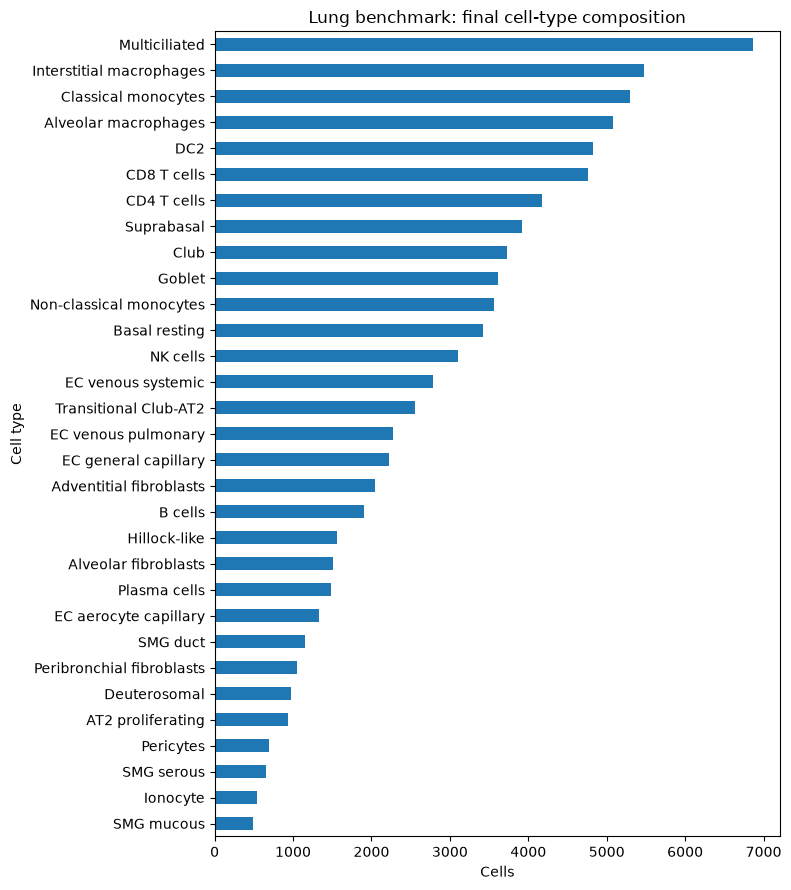

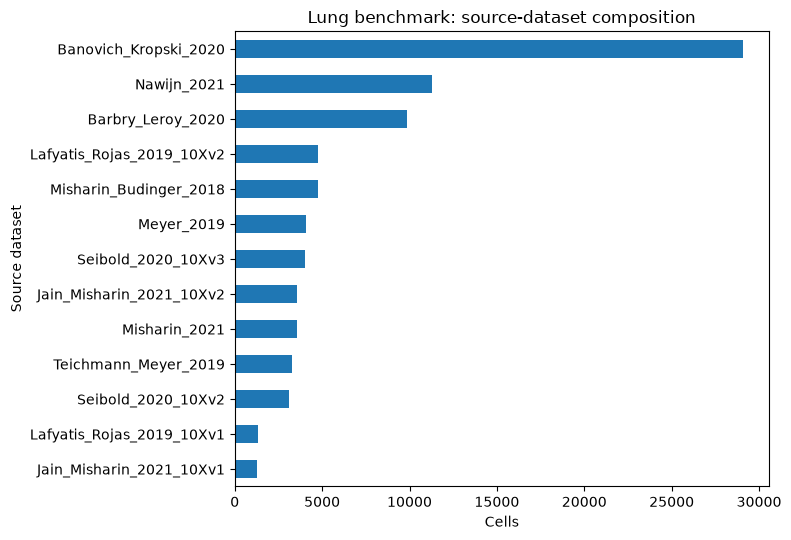

In [3]:
adata_backed = ad.read_h5ad(ADATA_PATH, backed="r")
overview = pd.DataFrame([{
    "cells": adata_backed.n_obs,
    "HVGs": adata_backed.n_vars,
    "donors": adata_backed.obs["donor_id"].astype(str).nunique(),
    "cell_types": adata_backed.obs["cell_type"].astype(str).nunique(),
    "source_datasets": adata_backed.obs["batch"].astype(str).nunique(),
    "PCA_dims": adata_backed.obsm["X_pca"].shape[1],
    "Harmony_dims": adata_backed.obsm["X_harmony"].shape[1],
    "scVI_dims": adata_backed.obsm["X_scVI"].shape[1],
}])
display(overview)

celltype_counts = adata_backed.obs["cell_type"].astype(str).value_counts().sort_values()
batch_counts = adata_backed.obs["batch"].astype(str).value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
celltype_counts.plot.barh(ax=ax)
ax.set_xlabel("Cells")
ax.set_ylabel("Cell type")
ax.set_title("Lung benchmark: final cell-type composition")
fig.tight_layout()
fig.savefig(FIG_DIR / "lung_celltype_composition.pdf", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5.5))
batch_counts.plot.barh(ax=ax)
ax.set_xlabel("Cells")
ax.set_ylabel("Source dataset")
ax.set_title("Lung benchmark: source-dataset composition")
fig.tight_layout()
fig.savefig(FIG_DIR / "lung_batch_composition.pdf", bbox_inches="tight")
plt.show()

if hasattr(adata_backed, "file") and adata_backed.file is not None:
    adata_backed.file.close()

## 3. UMAPs from the frozen PCA representation

UMAP is a **display-only derived artifact**. The benchmark-ready `.h5ad` is never modified; coordinates are cached in `results/figure_data/lung_umap_pca.csv`.

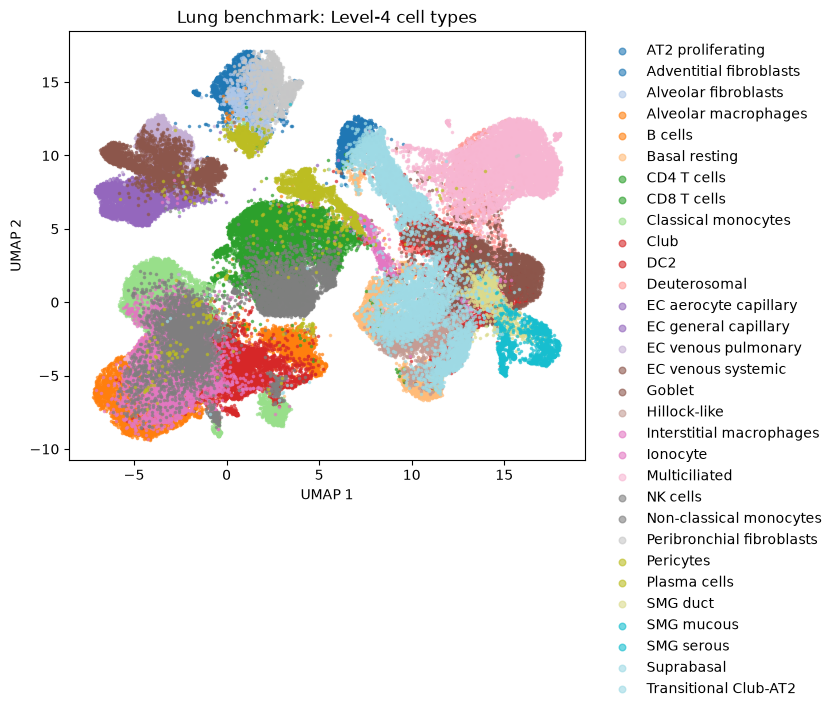

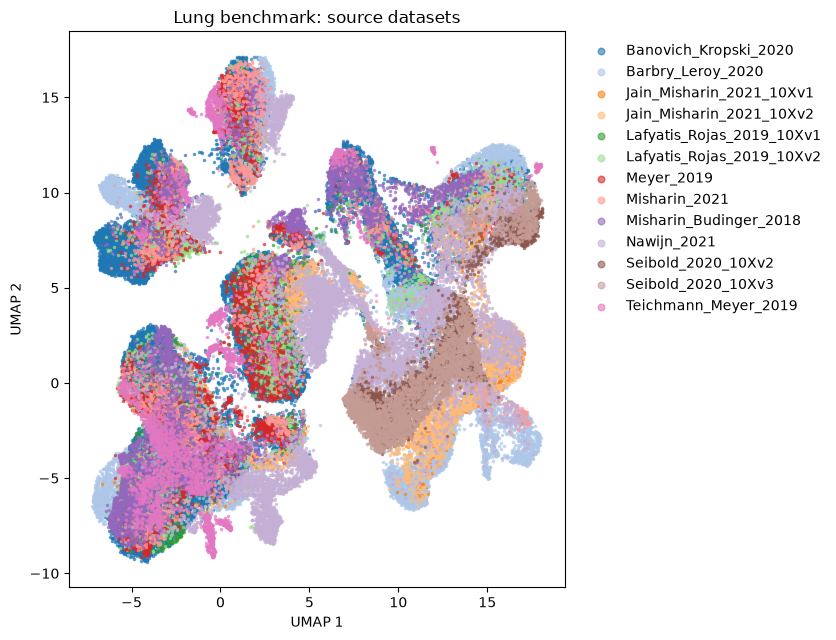

In [4]:
def get_or_make_umap():
    cache = CACHE_DIR / "lung_umap_pca.csv"
    if cache.exists():
        return pd.read_csv(cache, index_col=0)

    adata = ad.read_h5ad(ADATA_PATH)
    sc.pp.neighbors(adata, use_rep="X_pca", random_state=42)
    sc.tl.umap(adata, random_state=42)
    coords = pd.DataFrame(
        adata.obsm["X_umap"],
        index=adata.obs_names.astype(str),
        columns=["UMAP1", "UMAP2"],
    )
    coords["cell_type"] = adata.obs["cell_type"].astype(str).to_numpy()
    coords["batch"] = adata.obs["batch"].astype(str).to_numpy()
    coords["donor_id"] = adata.obs["donor_id"].astype(str).to_numpy()
    coords.to_csv(cache)
    return coords

def plot_categorical_umap(coords, column, title, out_name):
    categories = sorted(coords[column].astype(str).unique())
    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    cmap = plt.get_cmap("tab20", max(20, len(categories)))
    for i, label in enumerate(categories):
        sub = coords[coords[column].astype(str) == label]
        ax.scatter(
            sub["UMAP1"], sub["UMAP2"],
            s=2.5, alpha=0.6, label=label, color=cmap(i), rasterized=True,
        )
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_title(title)
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=3)
    fig.tight_layout()
    fig.savefig(FIG_DIR / out_name, bbox_inches="tight")
    plt.show()

coords = get_or_make_umap()
plot_categorical_umap(coords, "cell_type", "Lung benchmark: Level-4 cell types", "lung_umap_celltype.pdf")
plot_categorical_umap(coords, "batch", "Lung benchmark: source datasets", "lung_umap_batch.pdf")

## 4. Primary evaluation: random cell split vs donor-held-out CV

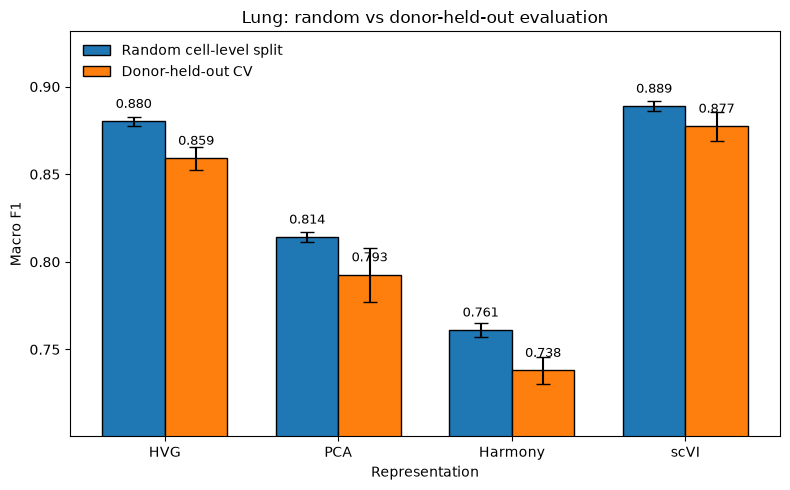

In [5]:
plot_random_vs_donor_cv(
    PRIMARY_DIR / "random_split/random_split_repeated_metrics.csv",
    PRIMARY_DIR / "donor_cv/metrics.csv",
    out_file=FIG_DIR / "lung_random_vs_donor.pdf",
    title="Lung: random vs donor-held-out evaluation",
)
plt.show()

## 5. Source-dataset covariate sensitivity

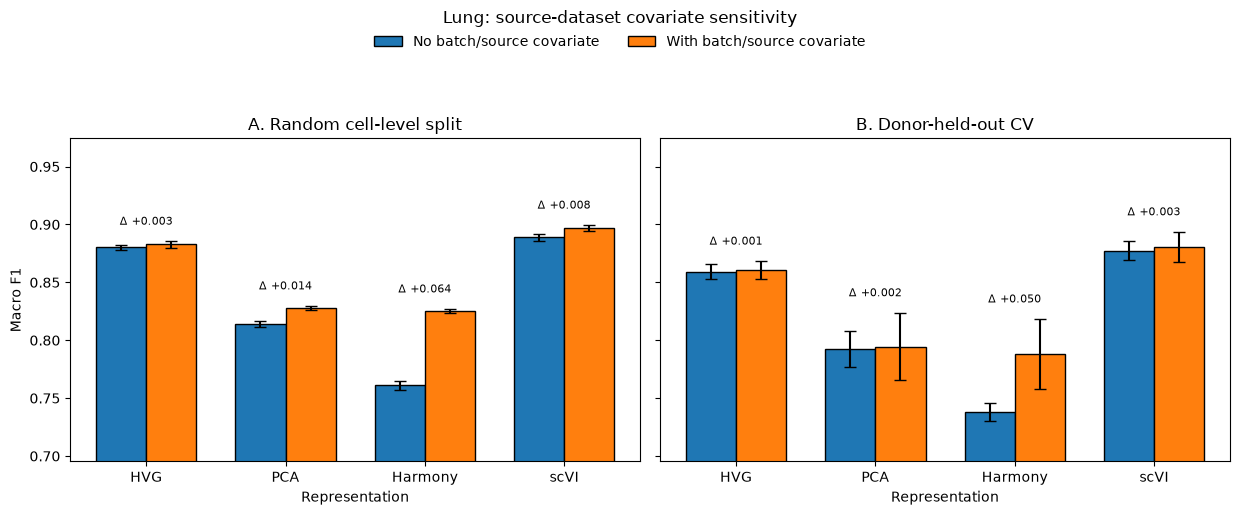

In [6]:
plot_batch_covariate_by_scheme(
    PRIMARY_DIR / "donor_cv/metrics.csv",
    BATCH_DIR / "donor_cv/metrics.csv",
    out_file=FIG_DIR / "lung_batch_covariate_sensitivity.pdf",
    title="Lung: source-dataset covariate sensitivity",
)
plt.show()

## 6. Donor-ablation analysis

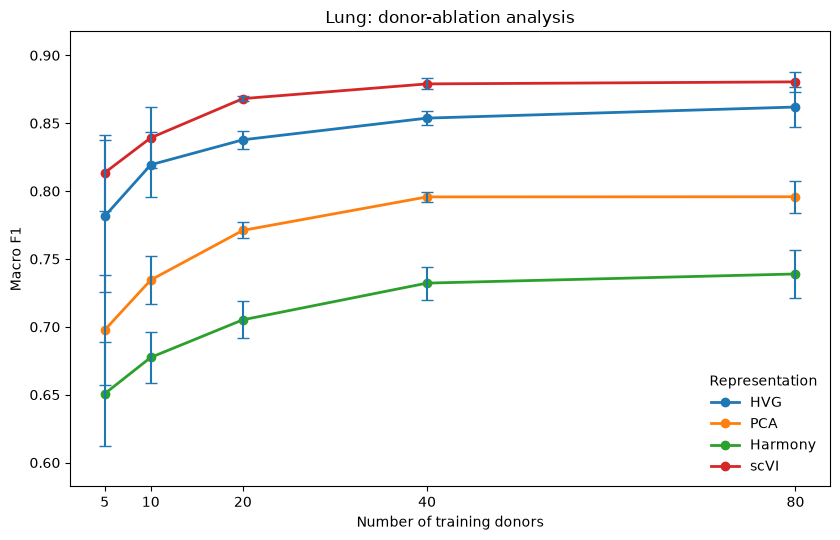

In [7]:
plot_donor_ablation(
    PRIMARY_DIR / "donor_ablation/donor_ablation_summary.csv",
    out_file=FIG_DIR / "lung_donor_ablation.pdf",
    title="Lung: donor-ablation analysis",
)
plt.show()

## 7. Per-class donor-held-out F1

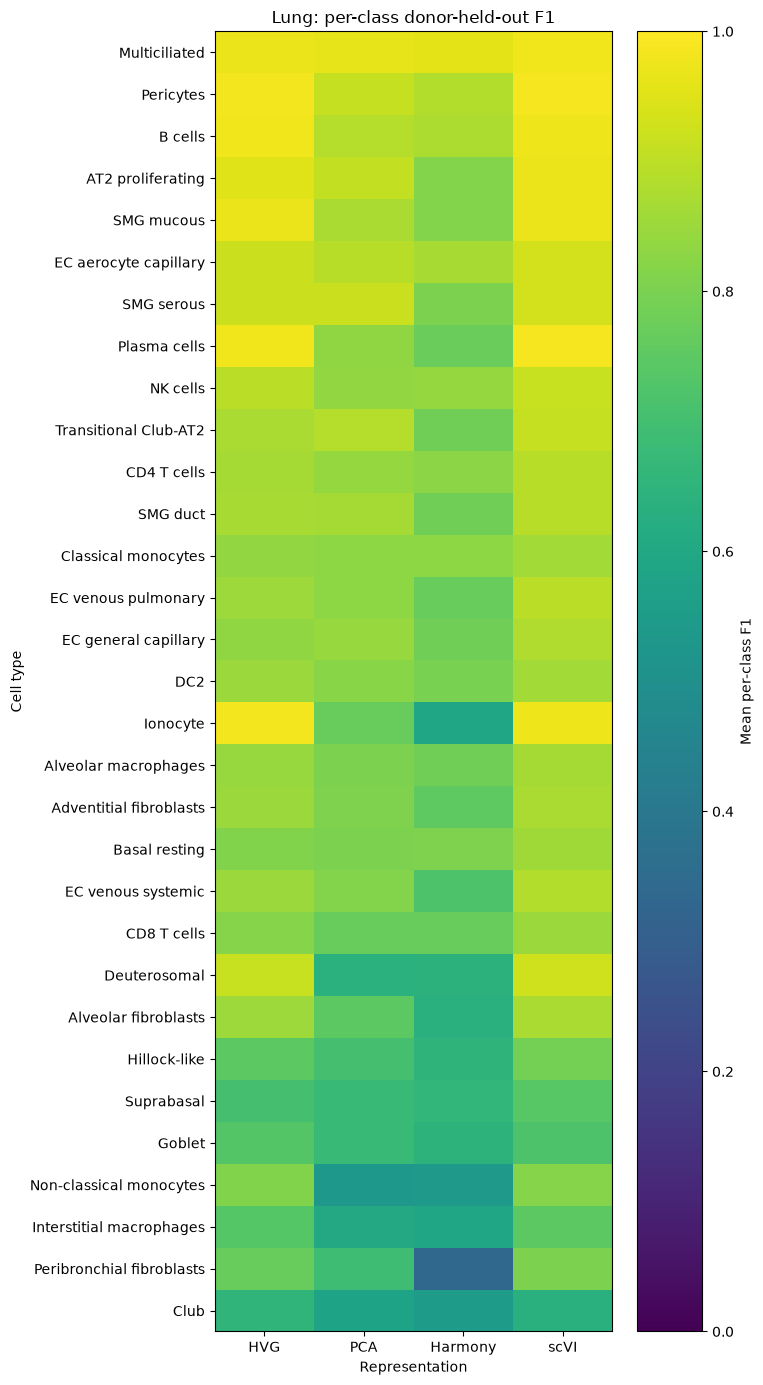

In [8]:
f1_matrix = load_per_class_f1_matrix(PRIMARY_DIR / "donor_cv")
plot_per_class_f1_heatmap(
    f1_matrix,
    annotate=False,
    out_file=FIG_DIR / "lung_per_class_f1.pdf",
    title="Lung: per-class donor-held-out F1",
)
plt.show()

## 8. Representative pooled donor-CV confusion matrix

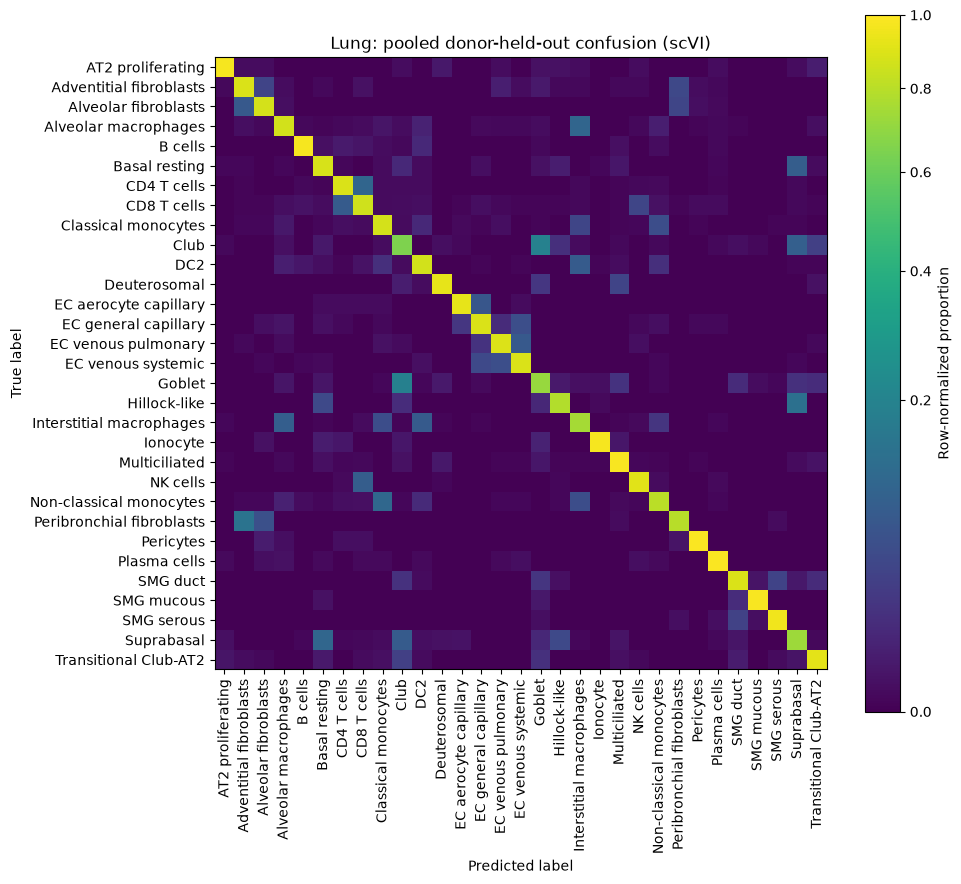

In [9]:
REPRESENTATIVE_REP = "scvi"
pred_path = PRIMARY_DIR / "donor_cv" / f"donor_cv_{REPRESENTATIVE_REP}_all_predictions.csv"
plot_confusion_matrix_from_predictions(
    pred_path,
    out_file=FIG_DIR / f"lung_{REPRESENTATIVE_REP}_confusion.pdf",
    title=f"Lung: pooled donor-held-out confusion ({DEFAULT_REP_LABELS[REPRESENTATIVE_REP]})",
)
plt.show()

## 9. Correctness GLMM sensitivity

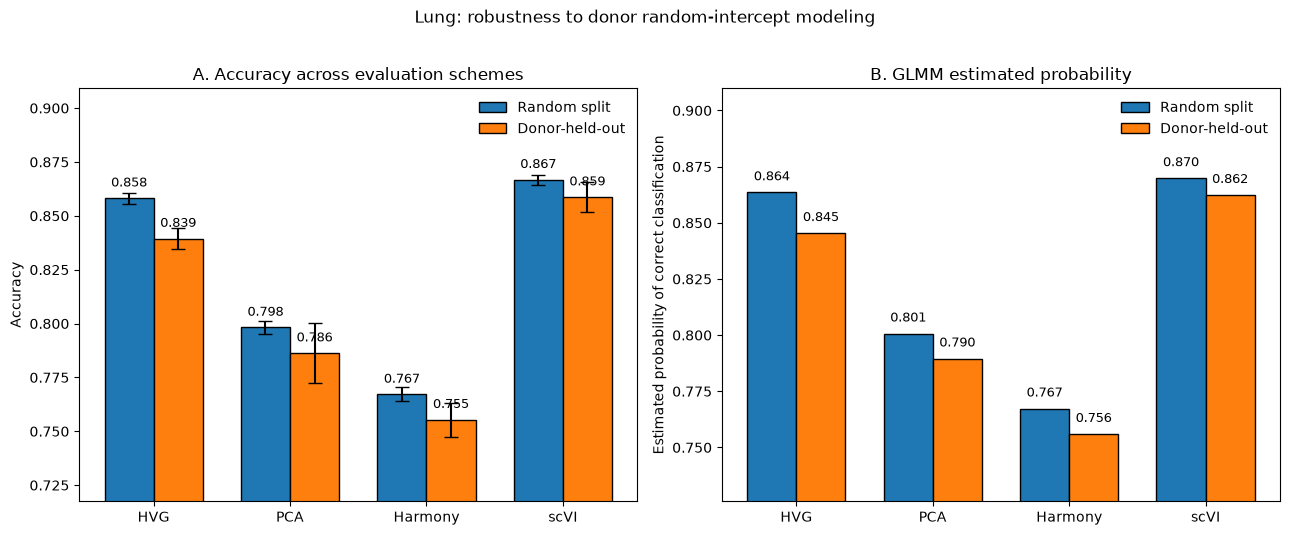

In [10]:
plot_glmm_scheme_comparison(
    PRIMARY_DIR / "random_split/random_split_repeated_metrics.csv",
    PRIMARY_DIR / "donor_cv/metrics.csv",
    PRIMARY_DIR / "mixed_models/correctness_glmm_predicted_probabilities.csv",
    out_file=FIG_DIR / "lung_glmm_scheme_comparison.pdf",
    title="Lung: robustness to donor random-intercept modeling",
)
plt.show()

## 10. Evaluation-inflation summary

,representation,random_macro_f1,donor_macro_f1,analysis,inflation_delta
0,harmony,0.761050,0.737988,No batch covariate,0.023062
1,hvg,0.880128,0.859064,No batch covariate,0.021065
2,pca,0.814087,0.792558,No batch covariate,0.021529
3,scvi,0.888792,0.877423,No batch covariate,0.011369
4,harmony,0.825055,0.788302,With batch covariate,0.036753
5,hvg,0.882739,0.860425,With batch covariate,0.022314
6,pca,0.827810,0.794477,With batch covariate,0.033333
7,scvi,0.897034,0.880744,With batch covariate,0.016290


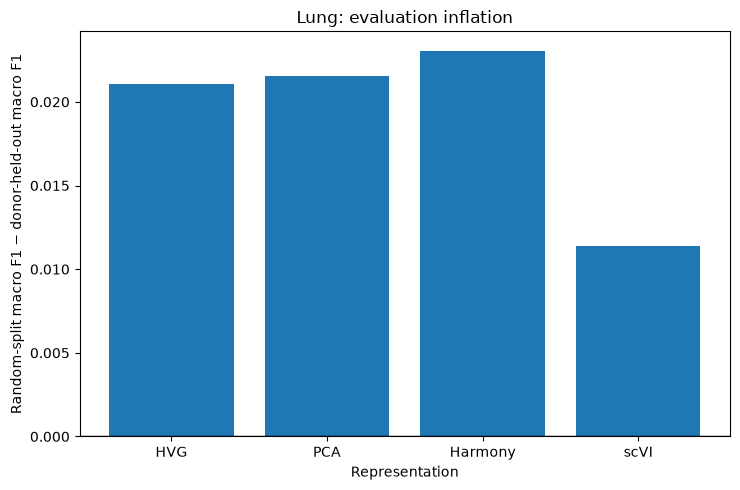

In [11]:
def inflation_table(result_dir, analysis_label):
    random_df = pd.read_csv(result_dir / "random_split/random_split_repeated_metrics.csv")
    donor_df = pd.read_csv(result_dir / "donor_cv/metrics.csv")
    random_mean = (
        random_df.groupby("representation", as_index=False)["macro_f1"].mean()
        .rename(columns={"macro_f1": "random_macro_f1"})
    )
    donor_keep = donor_df[["representation", "macro_f1_mean"]].rename(
        columns={"macro_f1_mean": "donor_macro_f1"}
    )
    out = random_mean.merge(donor_keep, on="representation", how="inner")
    out["analysis"] = analysis_label
    out["inflation_delta"] = out["random_macro_f1"] - out["donor_macro_f1"]
    return out

inflation = pd.concat([
    inflation_table(PRIMARY_DIR, "No batch covariate"),
    inflation_table(BATCH_DIR, "With batch covariate"),
], ignore_index=True)
display(inflation.sort_values(["analysis", "representation"]))
inflation.to_csv(CACHE_DIR / "lung_inflation_summary.csv", index=False)

primary = inflation[inflation["analysis"] == "No batch covariate"].set_index("representation")
rep_order = [r for r in DEFAULT_REP_ORDER if r in primary.index]
fig, ax = plt.subplots(figsize=(7.5, 5))
vals = primary.reindex(rep_order)["inflation_delta"]
ax.bar(np.arange(len(rep_order)), vals)
ax.axhline(0, linewidth=1, color="black")
ax.set_xticks(np.arange(len(rep_order)))
ax.set_xticklabels([DEFAULT_REP_LABELS.get(r, r) for r in rep_order])
ax.set_xlabel("Representation")
ax.set_ylabel("Random-split macro F1 − donor-held-out macro F1")
ax.set_title("Lung: evaluation inflation")
fig.tight_layout()
fig.savefig(FIG_DIR / "lung_inflation_effect.pdf", bbox_inches="tight")
plt.show()

## Figure outputs

All exported lung panels are under `figures/lung/`. The notebook intentionally does not contain any classifier fitting, donor-fold creation, donor ablation, or GLMM fitting.